# Model Quantization: Making Large Language Models Smaller and Faster

In the previous notebook, we explored how a language model generates text one token at a time using autoregressive decoding, temperature, and sampling.

That naturally leads to a deployment question:

> How can we make large language models smaller, faster, and cheaper to run?

This notebook answers that question through **model quantization**: the practice of representing model weights and/or activations with fewer bits while preserving most of the model's behavior.

We will combine intuition, memory math, visualizations, and small NumPy experiments. No GPU or deep learning framework is required.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain why quantization matters for LLM deployment
- Compare FP32, FP16, BF16, INT8, and INT4 representations
- Estimate memory usage for models of different sizes
- Implement simple min-max quantization from scratch
- Measure reconstruction error after quantization
- Understand practical trade-offs between speed, memory, and quality
- Recognize where GPTQ, AWQ, BitsAndBytes, and GGUF fit in real workflows

In [1]:
import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


plt.style.use("seaborn-v0_8-whitegrid")

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

## Why Quantization Exists

Modern LLMs contain billions of parameters. During inference, those parameters must be loaded from memory and moved through GPU or CPU compute units repeatedly.

This creates pressure on:

- **Memory capacity**: Can the model fit on the device?
- **Memory bandwidth**: How fast can weights be read?
- **Latency**: How quickly can each token be generated?
- **Cost**: How many and what kind of accelerators are required?

Quantization reduces the number of bits used to store numerical values. If a model can use 8-bit or 4-bit weights instead of 16-bit or 32-bit weights, it can become dramatically cheaper to store and serve.

## One Billion Numbers

Imagine storing **one billion parameters**. The architecture is unchanged. The number of parameters is unchanged. Only the numeric representation changes.

In [2]:
def bytes_to_gib(num_bytes):
    """Convert bytes to gibibytes."""
    return num_bytes / (1024 ** 3)


precision_bits = {
    "FP32": 32,
    "FP16": 16,
    "BF16": 16,
    "INT8": 8,
    "INT4": 4,
}


def memory_for_parameters(num_parameters, bits_per_parameter):
    """Return memory in bytes for a parameter count and precision."""
    return num_parameters * bits_per_parameter / 8


one_billion_rows = []
for precision, bits in precision_bits.items():
    memory_bytes = memory_for_parameters(1_000_000_000, bits)
    one_billion_rows.append(
        {
            "Precision": precision,
            "Bits / parameter": bits,
            "Memory (GiB)": bytes_to_gib(memory_bytes),
            "Relative to FP32": bits / 32,
        }
    )

one_billion_df = pd.DataFrame(one_billion_rows)
one_billion_df

,Precision,Bits / parameter,Memory (GiB),Relative to FP32
0,FP32,32,3.725290,1.000
1,FP16,16,1.862645,0.500
2,BF16,16,1.862645,0.500
3,INT8,8,0.931323,0.250
4,INT4,4,0.465661,0.125


The important intuition:

- FP32 is accurate but expensive.
- FP16 and BF16 cut memory roughly in half.
- INT8 cuts memory to one quarter of FP32.
- INT4 cuts memory to one eighth of FP32.

For LLM inference, that difference can determine whether a model fits on a single device at all.

## Floating Point vs Integer Representation

LLMs are trained with floating-point numbers because training needs small gradient updates and a wide dynamic range.

For inference, we often do not need the same level of numerical detail. Quantization maps floating-point values into a smaller integer range and stores scale information so the values can be approximately reconstructed.

In [3]:
precision_comparison = pd.DataFrame(
    [
        {
            "Format": "FP32",
            "Bits": 32,
            "Typical use": "Training, evaluation, high precision baselines",
            "Strength": "High precision and wide range",
            "Trade-off": "Large memory footprint",
        },
        {
            "Format": "FP16",
            "Bits": 16,
            "Typical use": "GPU inference and mixed-precision training",
            "Strength": "Fast on many accelerators",
            "Trade-off": "Narrower range than FP32",
        },
        {
            "Format": "BF16",
            "Bits": 16,
            "Typical use": "Training and inference on modern accelerators",
            "Strength": "FP32-like range with lower memory",
            "Trade-off": "Less mantissa precision than FP16",
        },
        {
            "Format": "INT8",
            "Bits": 8,
            "Typical use": "Production inference, CPU/GPU acceleration",
            "Strength": "Strong memory reduction with good quality",
            "Trade-off": "Needs calibration or careful scaling",
        },
        {
            "Format": "INT4",
            "Bits": 4,
            "Typical use": "Memory-constrained LLM inference",
            "Strength": "Very high compression",
            "Trade-off": "More quality risk and specialized kernels",
        },
    ]
)

precision_comparison

,Format,Bits,Typical use,Strength,Trade-off
0,FP32,32,"Training, evaluation, high precision baselines",High precision and wide range,Large memory footprint
1,FP16,16,GPU inference and mixed-precision training,Fast on many accelerators,Narrower range than FP32
2,BF16,16,Training and inference on modern accelerators,FP32-like range with lower memory,Less mantissa precision than FP16
3,INT8,8,"Production inference, CPU/GPU acceleration",Strong memory reduction with good quality,Needs calibration or careful scaling
4,INT4,4,Memory-constrained LLM inference,Very high compression,More quality risk and specialized kernels


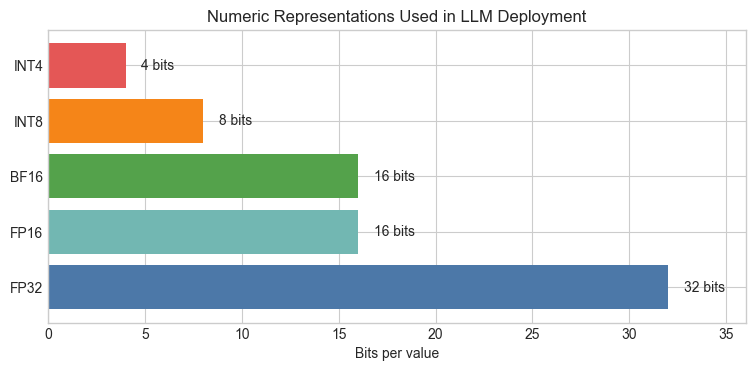

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.8))
formats = list(precision_bits.keys())
bits = [precision_bits[name] for name in formats]
colors = ["#4c78a8", "#72b7b2", "#54a24b", "#f58518", "#e45756"]

ax.barh(formats, bits, color=colors)
ax.set_xlabel("Bits per value")
ax.set_title("Numeric Representations Used in LLM Deployment")
ax.set_xlim(0, 36)

for index, value in enumerate(bits):
    ax.text(value + 0.8, index, f"{value} bits", va="center")

plt.show()

## Memory Calculation for Common Model Sizes

A rough memory estimate for model weights is:

```text
memory = number_of_parameters * bits_per_parameter / 8
```

This does not include KV cache, optimizer states, framework overhead, activation buffers, or fragmentation. For inference planning, however, weight memory is the first number to understand.

In [5]:
MODEL_SIZES = {
    "100M": 100_000_000,
    "500M": 500_000_000,
    "1B": 1_000_000_000,
    "7B": 7_000_000_000,
    "13B": 13_000_000_000,
}

DEPLOYMENT_PRECISIONS = {
    "FP32": 32,
    "FP16": 16,
    "INT8": 8,
    "INT4": 4,
}


def build_memory_table(model_sizes, precision_map):
    """Build a memory table in GiB for model size and precision pairs."""
    rows = []
    for model_name, parameter_count in model_sizes.items():
        row = {"Model size": model_name, "Parameters": parameter_count}
        for precision_name, bits in precision_map.items():
            row[precision_name] = bytes_to_gib(
                memory_for_parameters(parameter_count, bits)
            )
        rows.append(row)
    return pd.DataFrame(rows)


memory_df = build_memory_table(MODEL_SIZES, DEPLOYMENT_PRECISIONS)
memory_df

,Model size,Parameters,FP32,FP16,INT8,INT4
0,100M,100000000,0.372529,0.186265,0.093132,0.046566
1,500M,500000000,1.862645,0.931323,0.465661,0.232831
2,1B,1000000000,3.725290,1.862645,0.931323,0.465661
3,7B,7000000000,26.077032,13.038516,6.519258,3.259629
4,13B,13000000000,48.428774,24.214387,12.107193,6.053597


## Visualization: Memory Consumption

The same architecture can have very different deployment requirements depending on precision.

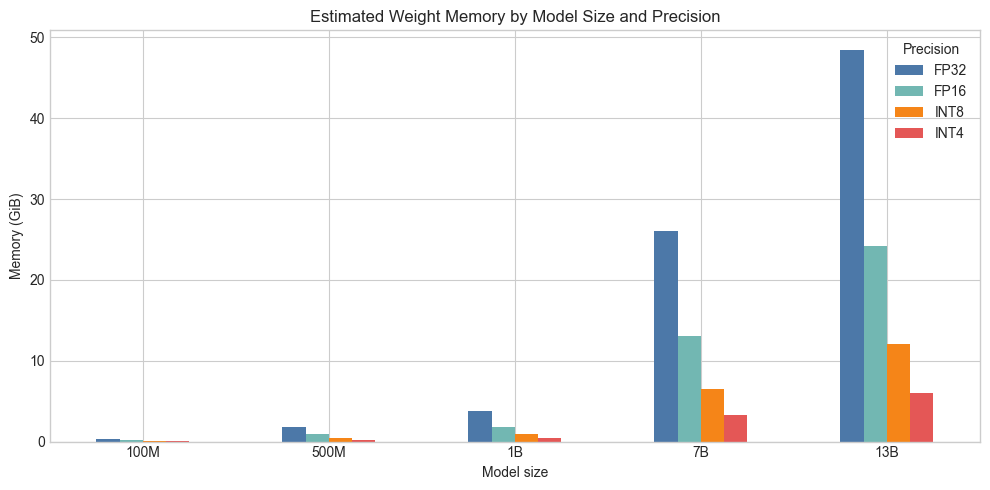

In [6]:
plot_df = memory_df.set_index("Model size")[list(DEPLOYMENT_PRECISIONS.keys())]

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#4c78a8", "#72b7b2", "#f58518", "#e45756"],
)
ax.set_title("Estimated Weight Memory by Model Size and Precision")
ax.set_ylabel("Memory (GiB)")
ax.set_xlabel("Model size")
ax.legend(title="Precision")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

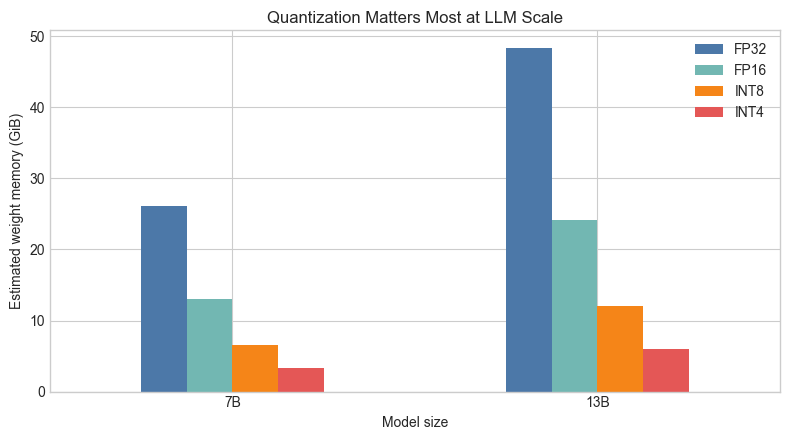

In [7]:
large_models_df = memory_df[memory_df["Model size"].isin(["7B", "13B"])]
large_plot_df = large_models_df.set_index("Model size")[
    list(DEPLOYMENT_PRECISIONS.keys())
]

ax = large_plot_df.plot(
    kind="bar",
    figsize=(8, 4.5),
    color=["#4c78a8", "#72b7b2", "#f58518", "#e45756"],
)
ax.set_title("Quantization Matters Most at LLM Scale")
ax.set_ylabel("Estimated weight memory (GiB)")
ax.set_xlabel("Model size")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## What Happens During Quantization?

At a high level:

1. Start with floating-point weights.
2. Choose an integer range, such as INT8 from -128 to 127.
3. Compute a scale factor that maps floating-point values into that integer range.
4. Store the integer values and the scale.
5. During inference, use integer kernels directly or approximately recover floating-point values when needed.

The recovered values are not identical. Quantization is a compression method, and compression introduces error.

In [8]:
toy_weights = np.array([0.923, -0.441, 0.013, 1.204, -1.000, 0.512])


def symmetric_quantize(values, num_bits=8):
    """Symmetrically quantize values around zero."""
    values = np.asarray(values, dtype=np.float32)
    max_abs = np.max(np.abs(values))
    qmax = 2 ** (num_bits - 1) - 1
    scale = max_abs / qmax if max_abs != 0 else 1.0
    quantized = np.round(values / scale).clip(-qmax - 1, qmax).astype(np.int32)
    recovered = quantized.astype(np.float32) * scale
    return quantized, recovered, scale


toy_quantized, toy_recovered, toy_scale = symmetric_quantize(toy_weights, 8)

pd.DataFrame(
    {
        "Original": toy_weights,
        "Quantized INT8": toy_quantized,
        "Recovered": toy_recovered,
        "Absolute error": np.abs(toy_weights - toy_recovered),
    }
)

,Original,Quantized INT8,Recovered,Absolute error
0,0.923,97,0.919591,3.409408e-03
1,-0.441,-47,-0.445575,4.574820e-03
2,0.013,1,0.009480,3.519685e-03
3,1.204,127,1.204000,3.814697e-09
4,-1.000,-105,-0.995433,4.566908e-03
5,0.512,54,0.511937,6.297779e-05


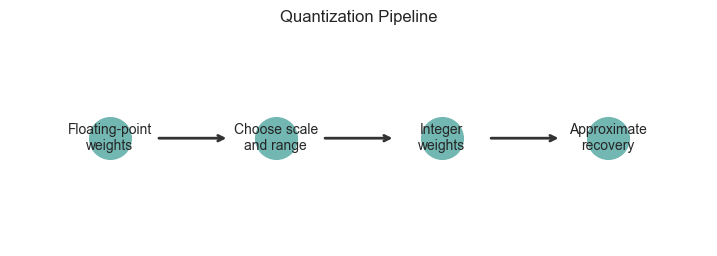

In [9]:
fig, ax = plt.subplots(figsize=(9, 2.8))

pipeline_steps = [
    "Floating-point\nweights",
    "Choose scale\nand range",
    "Integer\nweights",
    "Approximate\nrecovery",
]
x_positions = np.arange(len(pipeline_steps))

ax.scatter(x_positions, np.zeros_like(x_positions), s=900, color="#72b7b2")
for x_pos, label in zip(x_positions, pipeline_steps):
    ax.text(x_pos, 0, label, ha="center", va="center", fontsize=10)

for start in x_positions[:-1]:
    ax.annotate(
        "",
        xy=(start + 0.72, 0),
        xytext=(start + 0.28, 0),
        arrowprops={"arrowstyle": "->", "lw": 2, "color": "#333333"},
    )

ax.set_title("Quantization Pipeline")
ax.set_xlim(-0.6, len(pipeline_steps) - 0.4)
ax.set_ylim(-0.7, 0.7)
ax.axis("off")
plt.show()

## Simple Quantization From Scratch

Next we implement min-max quantization with NumPy only.

Min-max quantization maps the smallest floating-point value to the smallest integer and the largest floating-point value to the largest integer. Values in between are linearly mapped.

In [10]:
@dataclass
class QuantizationResult:
    """Container for quantization outputs and metadata."""

    quantized: np.ndarray
    dequantized: np.ndarray
    scale: float
    zero_point: int
    qmin: int
    qmax: int
    mse: float
    max_error: float


def get_integer_range(num_bits, signed=True):
    """Return the inclusive integer range for a precision."""
    if signed:
        return -(2 ** (num_bits - 1)), 2 ** (num_bits - 1) - 1
    return 0, 2 ** num_bits - 1


def min_max_quantize(values, num_bits=8, signed=True):
    """Quantize and dequantize an array using min-max affine quantization."""
    values = np.asarray(values, dtype=np.float32)
    qmin, qmax = get_integer_range(num_bits, signed=signed)
    min_value = float(np.min(values))
    max_value = float(np.max(values))

    if math.isclose(max_value, min_value):
        scale = 1.0
        zero_point = 0
        quantized = np.zeros_like(values, dtype=np.int32)
    else:
        scale = (max_value - min_value) / (qmax - qmin)
        zero_point = int(np.round(qmin - min_value / scale))
        zero_point = int(np.clip(zero_point, qmin, qmax))
        quantized = np.round(values / scale + zero_point)
        quantized = np.clip(quantized, qmin, qmax).astype(np.int32)

    dequantized = (quantized.astype(np.float32) - zero_point) * scale
    errors = values - dequantized

    return QuantizationResult(
        quantized=quantized,
        dequantized=dequantized,
        scale=scale,
        zero_point=zero_point,
        qmin=qmin,
        qmax=qmax,
        mse=float(np.mean(errors ** 2)),
        max_error=float(np.max(np.abs(errors))),
    )

In [11]:
sample_tensor = rng.normal(loc=0.0, scale=0.8, size=16).astype(np.float32)
result_8bit = min_max_quantize(sample_tensor, num_bits=8)

pd.DataFrame(
    {
        "Original": sample_tensor,
        "INT8 value": result_8bit.quantized,
        "Recovered": result_8bit.dequantized,
        "Error": sample_tensor - result_8bit.dequantized,
    }
)

,Original,INT8 value,Recovered,Error
0,0.243774,59,0.241433,0.002340
1,-0.831987,-52,-0.830531,-0.001456
2,0.600361,96,0.598755,0.001606
3,0.752452,112,0.753272,-0.000821
4,-1.560828,-128,-1.564489,0.003661
5,-1.041744,-74,-1.042993,0.001249
6,0.102272,45,0.106231,-0.003958
7,-0.252994,8,-0.251091,-0.001903
8,-0.013441,33,-0.009657,-0.003784
9,-0.682435,-37,-0.685671,0.003236


In [12]:
print(f"Scale: {result_8bit.scale:.6f}")
print(f"Zero point: {result_8bit.zero_point}")
print(f"MSE: {result_8bit.mse:.8f}")
print(f"Maximum error: {result_8bit.max_error:.8f}")

Scale: 0.009657
Zero point: 34
MSE: 0.00000834
Maximum error: 0.00453787


## Visualizing Quantization Error

For a larger tensor, we can see the distribution of reconstruction errors.

In [13]:
large_tensor = rng.normal(loc=0.0, scale=1.0, size=20_000).astype(np.float32)
large_result_8bit = min_max_quantize(large_tensor, num_bits=8)
large_result_4bit = min_max_quantize(large_tensor, num_bits=4)

error_8bit = large_tensor - large_result_8bit.dequantized
error_4bit = large_tensor - large_result_4bit.dequantized

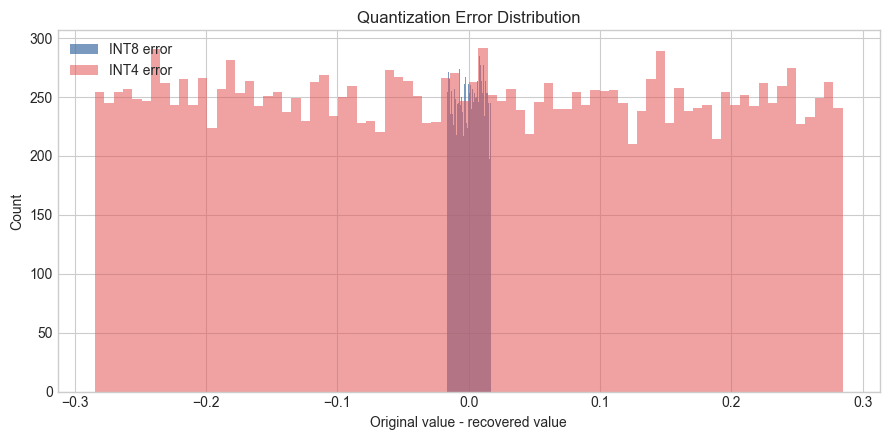

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(error_8bit, bins=80, alpha=0.75, label="INT8 error", color="#4c78a8")
ax.hist(error_4bit, bins=80, alpha=0.55, label="INT4 error", color="#e45756")
ax.set_title("Quantization Error Distribution")
ax.set_xlabel("Original value - recovered value")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

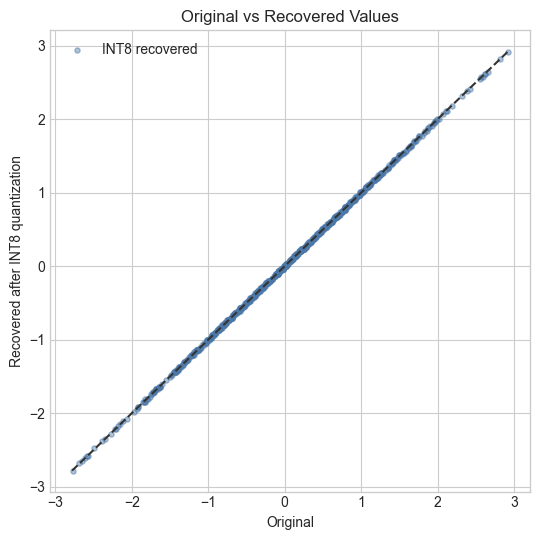

In [15]:
sample_indices = rng.choice(len(large_tensor), size=800, replace=False)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(
    large_tensor[sample_indices],
    large_result_8bit.dequantized[sample_indices],
    alpha=0.45,
    s=14,
    color="#4c78a8",
    label="INT8 recovered",
)
min_axis = min(np.min(large_tensor[sample_indices]), np.min(large_result_8bit.dequantized[sample_indices]))
max_axis = max(np.max(large_tensor[sample_indices]), np.max(large_result_8bit.dequantized[sample_indices]))
ax.plot([min_axis, max_axis], [min_axis, max_axis], color="#333333", linestyle="--")
ax.set_title("Original vs Recovered Values")
ax.set_xlabel("Original")
ax.set_ylabel("Recovered after INT8 quantization")
ax.legend()
plt.tight_layout()
plt.show()

## Precision vs Error

Lower precision usually means more compression and more reconstruction error.

The right choice depends on the model, task, hardware, and acceptable quality loss.

In [16]:
error_rows = []
for bits in [16, 8, 6, 4, 3, 2]:
    quant_result = min_max_quantize(large_tensor, num_bits=bits)
    original_memory = memory_for_parameters(large_tensor.size, 32)
    quantized_memory = memory_for_parameters(large_tensor.size, bits)
    error_rows.append(
        {
            "Precision": f"INT{bits}",
            "Bits": bits,
            "MSE": quant_result.mse,
            "Max error": quant_result.max_error,
            "Compression ratio vs FP32": original_memory / quantized_memory,
        }
    )

error_df = pd.DataFrame(error_rows)
error_df

,Precision,Bits,MSE,Max error,Compression ratio vs FP32
0,INT16,16,1.419334e-09,0.000065,2.000000
1,INT8,8,9.334627e-05,0.016746,4.000000
2,INT6,6,1.529827e-03,0.067773,5.333333
3,INT4,4,2.708433e-02,0.284676,8.000000
4,INT3,3,1.239055e-01,0.610018,10.666667
5,INT2,2,6.043956e-01,1.423385,16.000000


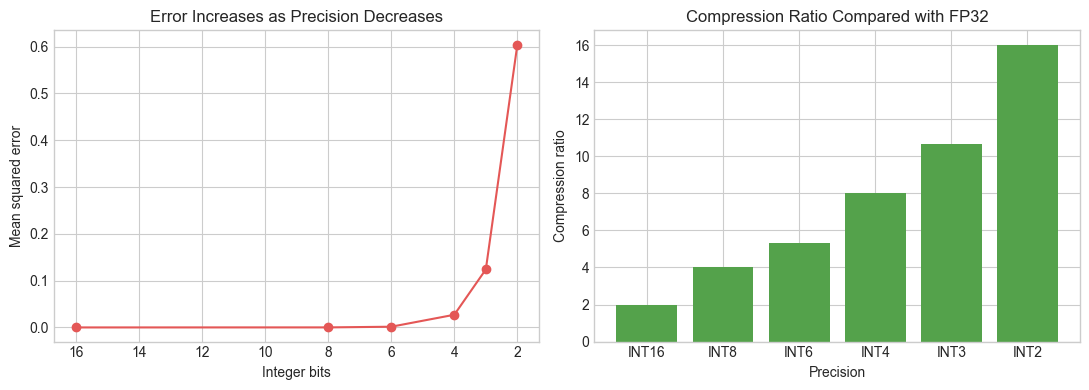

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(error_df["Bits"], error_df["MSE"], marker="o", color="#e45756")
axes[0].invert_xaxis()
axes[0].set_title("Error Increases as Precision Decreases")
axes[0].set_xlabel("Integer bits")
axes[0].set_ylabel("Mean squared error")

axes[1].bar(
    error_df["Precision"],
    error_df["Compression ratio vs FP32"],
    color="#54a24b",
)
axes[1].set_title("Compression Ratio Compared with FP32")
axes[1].set_xlabel("Precision")
axes[1].set_ylabel("Compression ratio")

plt.tight_layout()
plt.show()

## Dynamic, Static, Weight-Only, and Activation Quantization

Quantization can target different parts of inference.

In [18]:
quantization_modes = pd.DataFrame(
    [
        {
            "Technique": "Dynamic quantization",
            "What is quantized?": "Usually weights ahead of time; activations at runtime",
            "Best for": "Simple CPU inference workflows",
            "Trade-off": "Runtime scaling overhead",
        },
        {
            "Technique": "Static quantization",
            "What is quantized?": "Weights and activations using calibration data",
            "Best for": "Production pipelines with representative samples",
            "Trade-off": "Requires calibration and validation",
        },
        {
            "Technique": "Weight-only quantization",
            "What is quantized?": "Model weights",
            "Best for": "Large decoder-only LLM inference",
            "Trade-off": "Activations and KV cache may still be high precision",
        },
        {
            "Technique": "Activation quantization",
            "What is quantized?": "Intermediate activations",
            "Best for": "Reducing compute and bandwidth further",
            "Trade-off": "Can be more sensitive to outliers",
        },
    ]
)

quantization_modes

,Technique,What is quantized?,Best for,Trade-off
0,Dynamic quantization,Usually weights ahead of time; activations at ...,Simple CPU inference workflows,Runtime scaling overhead
1,Static quantization,Weights and activations using calibration data,Production pipelines with representative samples,Requires calibration and validation
2,Weight-only quantization,Model weights,Large decoder-only LLM inference,Activations and KV cache may still be high pre...
3,Activation quantization,Intermediate activations,Reducing compute and bandwidth further,Can be more sensitive to outliers


## Modern Quantization Techniques

Real LLM quantization uses more advanced methods than the simple min-max quantizer above.

| Technique | Intuition | Common use case |
|---|---|---|
| GPTQ | Post-training quantization that uses approximate second-order information to reduce the impact of weight rounding | Creating accurate 4-bit LLM checkpoints |
| AWQ | Activation-aware weight quantization that protects weights important for common activations | High-quality weight-only LLM quantization |
| BitsAndBytes | Practical library support for 8-bit and 4-bit loading, often used with Hugging Face workflows | Fast experimentation and fine-tuning setups |
| GGUF | File format used by llama.cpp-style runtimes for efficient local CPU/GPU inference | Local deployment and consumer hardware inference |

The key idea is the same: compress numerical representations while preserving model behavior as much as possible.

## Quantization Trade-offs

Quantization is useful because it changes deployment economics. It is not free.

In [19]:
tradeoff_table = pd.DataFrame(
    [
        {
            "Dimension": "Memory",
            "Typical effect": "Decreases",
            "Why it matters": "Larger models fit on smaller devices",
        },
        {
            "Dimension": "Bandwidth",
            "Typical effect": "Decreases",
            "Why it matters": "Weights can be moved faster",
        },
        {
            "Dimension": "Speed",
            "Typical effect": "Often increases",
            "Why it matters": "Lower latency and higher throughput",
        },
        {
            "Dimension": "Quality",
            "Typical effect": "May decrease slightly",
            "Why it matters": "Needs task-specific validation",
        },
        {
            "Dimension": "Complexity",
            "Typical effect": "Increases",
            "Why it matters": "Requires compatible kernels and careful testing",
        },
    ]
)

tradeoff_table

,Dimension,Typical effect,Why it matters
0,Memory,Decreases,Larger models fit on smaller devices
1,Bandwidth,Decreases,Weights can be moved faster
2,Speed,Often increases,Lower latency and higher throughput
3,Quality,May decrease slightly,Needs task-specific validation
4,Complexity,Increases,Requires compatible kernels and careful testing


## Mini Project: Quantization Simulator

Now we will package the ideas into a small simulator.

The function will accept:

- a tensor
- a target precision

It will return:

- estimated memory usage
- compressed tensor
- reconstructed tensor
- reconstruction error
- compression ratio

In [20]:
def simulate_quantization(tensor, precision):
    """Simulate affine quantization and report deployment-oriented metrics."""
    if isinstance(precision, str):
        precision = precision.upper().replace("INT", "")
        num_bits = int(precision)
    else:
        num_bits = int(precision)

    tensor = np.asarray(tensor, dtype=np.float32)
    result = min_max_quantize(tensor, num_bits=num_bits, signed=True)

    fp32_memory = memory_for_parameters(tensor.size, 32)
    quantized_memory = memory_for_parameters(tensor.size, num_bits)

    return {
        "precision": f"INT{num_bits}",
        "num_values": tensor.size,
        "fp32_memory_bytes": fp32_memory,
        "quantized_memory_bytes": quantized_memory,
        "fp32_memory_kib": fp32_memory / 1024,
        "quantized_memory_kib": quantized_memory / 1024,
        "compression_ratio": fp32_memory / quantized_memory,
        "compressed_tensor": result.quantized,
        "reconstructed_tensor": result.dequantized,
        "scale": result.scale,
        "zero_point": result.zero_point,
        "mse": result.mse,
        "max_error": result.max_error,
    }

In [21]:
sim_tensor = rng.normal(0, 0.7, size=(256, 256)).astype(np.float32)
simulation_rows = []

for precision in ["INT8", "INT4", "INT3", "INT2"]:
    output = simulate_quantization(sim_tensor, precision)
    simulation_rows.append(
        {
            "Precision": output["precision"],
            "Original memory (KiB)": output["fp32_memory_kib"],
            "Quantized memory (KiB)": output["quantized_memory_kib"],
            "Compression ratio": output["compression_ratio"],
            "MSE": output["mse"],
            "Max error": output["max_error"],
        }
    )

simulation_df = pd.DataFrame(simulation_rows)
simulation_df

,Precision,Original memory (KiB),Quantized memory (KiB),Compression ratio,MSE,Max error
0,INT8,256.0,64.0,4.000000,0.000054,0.012715
1,INT4,256.0,32.0,8.000000,0.015586,0.216165
2,INT3,256.0,24.0,10.666667,0.071372,0.463212
3,INT2,256.0,16.0,16.000000,0.327709,1.080812


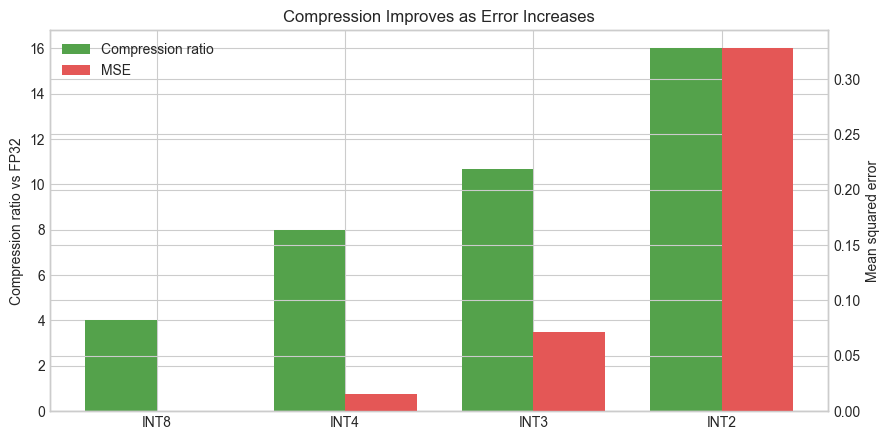

In [22]:
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax2 = ax1.twinx()

x = np.arange(len(simulation_df))
bar_width = 0.38

ax1.bar(
    x - bar_width / 2,
    simulation_df["Compression ratio"],
    width=bar_width,
    color="#54a24b",
    label="Compression ratio",
)
ax2.bar(
    x + bar_width / 2,
    simulation_df["MSE"],
    width=bar_width,
    color="#e45756",
    label="MSE",
)

ax1.set_xticks(x)
ax1.set_xticklabels(simulation_df["Precision"])
ax1.set_ylabel("Compression ratio vs FP32")
ax2.set_ylabel("Mean squared error")
ax1.set_title("Compression Improves as Error Increases")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()

## Practical Deployment Choices

There is no universally best precision. The right choice depends on the deployment target.

In [23]:
deployment_table = pd.DataFrame(
    [
        {
            "Precision": "FP32",
            "Use when": "You need a high-precision baseline or debugging reference",
            "Typical environment": "Research, validation, small models",
        },
        {
            "Precision": "FP16 / BF16",
            "Use when": "You want strong quality with accelerator-friendly inference",
            "Typical environment": "Cloud GPUs, production serving",
        },
        {
            "Precision": "INT8",
            "Use when": "You need lower memory and faster inference with modest quality risk",
            "Typical environment": "Cloud inference, CPUs, optimized GPUs",
        },
        {
            "Precision": "INT4",
            "Use when": "Memory is the main constraint and slight quality loss is acceptable",
            "Typical environment": "Consumer GPUs, local inference, edge-like setups",
        },
    ]
)

deployment_table

,Precision,Use when,Typical environment
0,FP32,You need a high-precision baseline or debuggin...,"Research, validation, small models"
1,FP16 / BF16,You want strong quality with accelerator-frien...,"Cloud GPUs, production serving"
2,INT8,You need lower memory and faster inference wit...,"Cloud inference, CPUs, optimized GPUs"
3,INT4,Memory is the main constraint and slight quali...,"Consumer GPUs, local inference, edge-like setups"


## Quantization in Real LLMs

Open-weight models such as **Llama**, **Mistral**, **Gemma**, **Qwen**, and **DeepSeek** are commonly distributed or converted into quantized formats.

In practice, teams often keep multiple variants:

- FP16 or BF16 for highest-quality serving
- INT8 for a strong memory-quality compromise
- INT4 for local or memory-constrained inference
- GGUF variants for llama.cpp-compatible local runtimes

The important production habit is to validate quantized models on the tasks users actually care about. A quantized model can look good in general but fail on a narrow workflow involving code, tool use, structured output, or domain-specific terminology.

## Common Misconceptions

**Quantization is not training.**  
Most quantization for deployment is post-training quantization. Quantization-aware training exists, but it is a separate workflow.

**Quantization does not change the architecture.**  
A quantized 7B model still has the same architecture and parameter count. The values are stored with fewer bits.

**A smaller model is not the same thing as a quantized model.**  
A 3B model and a 7B INT4 model are different ideas: one changes model size, the other changes numeric representation.

**Quantization is mainly an inference optimization.**  
It is most commonly used to reduce deployment cost, latency, and memory use.

## Production Checklist

Before deploying a quantized LLM, check:

- Does the model fit within memory after including KV cache?
- Does the runtime support the chosen quantization format?
- Are kernels optimized for the target hardware?
- Has quality been evaluated on real prompts?
- Are structured outputs, tool calls, and long-context behavior still reliable?
- Is latency better in the actual serving environment, not just in theory?

## Final Summary

Quantization matters because LLM inference is often limited by memory capacity, memory bandwidth, and cost.

The core idea is simple: store numerical values with fewer bits and accept a small amount of reconstruction error. Moving from FP32 to FP16, INT8, or INT4 can reduce weight memory dramatically.

In real deployments, quantization can make the difference between:

- a model that needs expensive cloud GPUs
- a model that fits on a consumer GPU
- a model that can run locally with CPU/GPU hybrid inference

The trade-off is that lower precision can reduce quality, especially for sensitive tasks. Good deployment engineering means measuring that trade-off instead of assuming it.

## Next Notebook

➡️ **Next: PEFT & Parameter-Efficient Fine-Tuning**

After making models efficient to run, the next challenge is adapting them to new tasks without retraining billions of parameters.

That is where parameter-efficient fine-tuning methods such as LoRA become important.